# Pipeline ABIDE organizado por método


In [1]:
# CELDA 1 - Configuracion general

from pathlib import Path
import os
import certifi
import json
import time

import numpy as np
import pandas as pd

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

NOTEBOOK_ROOT = Path.cwd()
EXTERNAL_DATA_ROOT = Path(os.environ.get("ABIDE_DATA_ROOT", r"D:/Carpeta Cristian/Datos_tesis"))
DATA_ROOT = EXTERNAL_DATA_ROOT if EXTERNAL_DATA_ROOT.exists() else NOTEBOOK_ROOT / "data"
DATA_DIR_FILT = DATA_ROOT / "ABIDE_pcp/cpac/filt_noglobal"
DATA_DIR_NOFILT = DATA_ROOT / "ABIDE_pcp/cpac/nofilt_noglobal"
if DATA_DIR_FILT.exists():
    DATA_DIR = DATA_DIR_FILT
    APPLY_BANDPASS = False  # ABIDE PCP ya aplico band-pass.
    DOWNLOAD_BANDPASS_FILTERING = True
else:
    DATA_DIR = DATA_DIR_NOFILT
    APPLY_BANDPASS = True
    DOWNLOAD_BANDPASS_FILTERING = False
PHENO = DATA_ROOT / "ABIDE_pcp/Phenotypic_V1_0b_preprocessed1.csv"

# Cohorte tipo paper: usar todos los sujetos validos disponibles sin forzar 482/482.
# Para una cohorte balanceada, usa USE_ALL_VALID_SUBJECTS=False y define N_PER_GROUP.
N_PER_GROUP = None
ALL_BALANCED = False
USE_ALL_VALID_SUBJECTS = True

# Experimento principal: Schaefer 100 con filtro temporal.
# MIN_TIMEPOINTS=146 exige mas timepoints que ROIs para estabilizar metodos multivariados/causales.
MAX_ROIS = 100
MIN_TIMEPOINTS = 146  # Usa None para no filtrar por longitud temporal.

# Activa esto si necesitas descargar/actualizar ABIDE antes de correr el pipeline.
RUN_DOWNLOAD = False  # Los NIfTI ya estan descargados en DATA_ROOT.
DOWNLOAD_RETRIES = 8
DOWNLOAD_RETRY_DELAY = 45

# LiNGAM es lento. Si quieres omitirlo temporalmente, usa False.
RUN_CAUSAL = True
CACHE_MATRICES = True
USE_CACHED_ROI_SIGNALS = False
SAVE_INDIVIDUAL_PLOTS = False
MAX_INDIVIDUAL_PLOTS = 20

# Figuras anatomicas por sujeto. Se deja apagado para que la celda de visualizacion no sea pesada.
RUN_SUBJECT_CONNECTOME_PLOTS = False
FILE_ID_VISOR = "Pitt_0050003"

CLASSIFIERS_TO_RUN = ["svm", "rf"]
N_SPLITS = 5
CV_STRATEGY = "group_site"  # Usa "stratified" solo para pruebas chicas, por ejemplo N_PER_GROUP=10.

MAXLAG = 1
TAU_MAX = 1
LINGAM_RANDOM_STATE = 42
GRANGER_LAG_STRATEGY = "min_q"
PCMCI_VALUE_MODE = "signed_logp"
ATLAS_NAME = "schaefer_100"

# Validacion tecnica previa para elegir alpha de Graphical Lasso sin usar el clasificador.
# Configuracion que reproduce los CSV de validacion guardados en esta entrega.
GRAPHICAL_LASSO_ALPHA_GRID = [0.05, 0.1, 0.2, 0.3, 0.5]
GRAPHICAL_LASSO_ALPHA_VALIDATION_SUBJECTS_PER_GROUP = 5
GRAPHICAL_LASSO_ALPHA_TARGET_DENSITY = 0.12
GRAPHICAL_LASSO_ALPHA_MIN_SUCCESS = 0.95
GRAPHICAL_LASSO_ALPHA_RANDOM_STATE = 42
GRAPHICAL_LASSO_ALPHA = None

N_TAG = "all_valid" if USE_ALL_VALID_SUBJECTS else ("all_balanced" if ALL_BALANCED else str(2 * N_PER_GROUP))
ROI_TAG = "allrois" if MAX_ROIS is None else f"{MAX_ROIS}rois"
TP_TAG = "alltp" if MIN_TIMEPOINTS is None else f"tp{MIN_TIMEPOINTS}"
OUT_MAIN = Path(f"resultados/pipeline_{ATLAS_NAME}_{N_TAG}_{ROI_TAG}_{TP_TAG}")
OUT_RESULTS = OUT_MAIN

SUBJECT_SELECTION = {
    "n_per_group": None if USE_ALL_VALID_SUBJECTS else N_PER_GROUP,
    "all_balanced": False if USE_ALL_VALID_SUBJECTS else ALL_BALANCED,
    "max_rois": MAX_ROIS,
    # APPLY_BANDPASS se define automaticamente segun DATA_DIR:
    # filt_noglobal -> False; nofilt_noglobal -> True.
    "apply_bandpass": APPLY_BANDPASS,
}

METHODS_ORDER = [
    "pearson",
    "graphical_lasso",
    "lingam",

    # Metodos excluidos del analisis principal actual:
    # "partial",
    # "granger",
    # "pcmci",
]
CAUSAL_METHODS = {"lingam"}
EXCLUDED_EXPERIMENTAL_METHODS = ["partial", "granger", "pcmci"]


In [2]:
# CELDA 2 - Cargar pipeline y descargar datos si hace falta

import importlib
import script.pipeline_abide as pipeline_abide
import script.descargar_abide as descargar_abide

importlib.reload(pipeline_abide)
importlib.reload(descargar_abide)

MIN_EXPECTED_FILES = 0 if USE_ALL_VALID_SUBJECTS else 2 * N_PER_GROUP

def contar_func_preproc():
    return len(list(DATA_DIR.glob("*_func_preproc.nii.gz"))) if DATA_DIR.exists() else 0

if RUN_DOWNLOAD:
    try:
        resumen_descarga = descargar_abide.run_download(
            data_dir=DATA_ROOT,
            n_per_group=None if USE_ALL_VALID_SUBJECTS else N_PER_GROUP,
            all_balanced=ALL_BALANCED,
            all_available=USE_ALL_VALID_SUBJECTS,
            pipeline="cpac",
            derivative="func_preproc",
            band_pass_filtering=DOWNLOAD_BANDPASS_FILTERING,
            global_signal_regression=False,
            repo_phenotypic=PHENO,
            download_retries=DOWNLOAD_RETRIES,
            retry_delay=DOWNLOAD_RETRY_DELAY,
        )
        display(resumen_descarga.head())
    except RuntimeError as exc:
        n_local = contar_func_preproc()
        print(exc)
        print(f"Archivos func_preproc disponibles localmente: {n_local}/{MIN_EXPECTED_FILES}")
        raise RuntimeError(
            "La descarga no se completo por conexion/DNS. "
            "Vuelve a ejecutar esta celda cuando internet este estable. "
            "No ejecutes las celdas del pipeline hasta tener la muestra completa."
        ) from exc
else:
    n_local = contar_func_preproc()
    print(f"RUN_DOWNLOAD=False: se usan archivos ya descargados ({n_local}/{MIN_EXPECTED_FILES}).")
    if n_local < MIN_EXPECTED_FILES:
        raise RuntimeError(
            "No hay suficientes archivos descargados para la muestra solicitada. "
            "Activa RUN_DOWNLOAD=True o baja N_PER_GROUP."
        )


RUN_DOWNLOAD=False: se usan archivos ya descargados (871/0).


## Preparación: sujetos, atlas y señales ROI


In [3]:
# CELDA 3 - Preparar sujetos y salidas compartidas

OUT_RESULTS.mkdir(parents=True, exist_ok=True)

subjects = None
if USE_CACHED_ROI_SIGNALS:
    try:
        cached_subjects = pipeline_abide.load_subjects_from_cached_roi_signals(
            output_dir=OUT_RESULTS,
            phenotypic_csv=PHENO,
            atlas_name=ATLAS_NAME,
            n_per_group=SUBJECT_SELECTION["n_per_group"],
            all_balanced=SUBJECT_SELECTION["all_balanced"],
            max_rois=SUBJECT_SELECTION["max_rois"],
        )
        n_nifti = len(list(DATA_DIR.rglob("*_func_preproc.nii.gz"))) if DATA_DIR.exists() else 0
        if USE_ALL_VALID_SUBJECTS and n_nifti and len(cached_subjects) < n_nifti:
            print(
                f"[AVISO] Cache ROI parcial: {len(cached_subjects)} sujetos cacheados "
                f"vs {n_nifti} NIfTI disponibles. Se continuara por NIfTI reutilizando caches existentes."
            )
        else:
            subjects = cached_subjects
            print(f"Usando senales ROI cacheadas: {len(subjects)} sujetos.")
    except (FileNotFoundError, ValueError) as exc:
        print(f"[AVISO] No se pudo usar cache ROI completa: {exc}")

if subjects is None:
    subjects = pipeline_abide.load_subjects_from_nifti_atlas(
        fmri_dir=DATA_DIR,
        phenotypic_csv=PHENO,
        output_dir=OUT_RESULTS,
        atlas_name=ATLAS_NAME,
        **SUBJECT_SELECTION,
    )

subjects_all_timepoints = list(subjects)
MIN_TIMEPOINTS_RULE = MIN_TIMEPOINTS if MIN_TIMEPOINTS is not None else subjects[0].roi_signals_z.shape[1] + 1

timepoints_by_site_pre = pipeline_abide.build_timepoint_site_table(
    subjects_all_timepoints,
    min_timepoints=MIN_TIMEPOINTS_RULE,
)
timepoints_site_pre_path = OUT_RESULTS / "resumen_timepoints_por_sitio_pre_filtro.csv"
timepoints_by_site_pre.to_csv(timepoints_site_pre_path, index=False)

n_subjects_before_filter = len(subjects)
if MIN_TIMEPOINTS is not None:
    labels_before = np.asarray([s.label for s in subjects])
    subjects = pipeline_abide.filter_subjects_by_timepoints(subjects, min_timepoints=MIN_TIMEPOINTS)
    labels_after = np.asarray([s.label for s in subjects])
    print(
        f"Filtro MIN_TIMEPOINTS>={MIN_TIMEPOINTS}: {len(subjects)}/{n_subjects_before_filter} sujetos conservados "
        f"| excluidos={n_subjects_before_filter - len(subjects)} "
        f"| TEA {int(np.sum(labels_before == 1))}->{int(np.sum(labels_after == 1))} "
        f"| Control {int(np.sum(labels_before == 0))}->{int(np.sum(labels_after == 0))}"
    )
else:
    print("MIN_TIMEPOINTS=None: no se filtran sujetos por longitud temporal.")

pipeline_abide.validate_subjects(subjects, atlas_name=ATLAS_NAME)
pipeline_abide.save_subject_manifest(subjects, OUT_RESULTS)

timepoints_by_site = pipeline_abide.build_timepoint_site_table(
    subjects,
    min_timepoints=MIN_TIMEPOINTS_RULE,
)
timepoints_site_path = OUT_RESULTS / "resumen_timepoints_por_sitio.csv"
timepoints_by_site.to_csv(timepoints_site_path, index=False)

stage_paths = pipeline_abide.save_stage_outputs(subjects, OUT_RESULTS)
stage_paths["timepoints_by_site_pre_filter"] = str(timepoints_site_pre_path)
stage_paths["timepoints_by_site"] = str(timepoints_site_path)

subject_plot_rows = []
method_matrix_paths = {}
method_matrix_stacks = {}
method_outputs = {}
method_failures = {}
datasets_vectorizados = {}

display(
    pd.DataFrame(
        {
            "n_sujetos": [len(subjects)],
            "n_excluidos_timepoints": [n_subjects_before_filter - len(subjects)],
            "TEA": [sum(s.label == 1 for s in subjects)],
            "Control": [sum(s.label == 0 for s in subjects)],
            "n_rois": [subjects[0].roi_signals_z.shape[1]],
            "min_timepoints": [min(s.roi_signals_z.shape[0] for s in subjects)],
            "max_timepoints": [max(s.roi_signals_z.shape[0] for s in subjects)],
            "min_timepoints_filtro": [MIN_TIMEPOINTS],
            "salida": [str(OUT_RESULTS)],
        }
    )
)

if MIN_TIMEPOINTS is not None:
    print("Resumen por sitio antes del filtro temporal:")
    display(timepoints_by_site_pre)

print("Resumen por sitio usado en el analisis:")
display(timepoints_by_site)



Cache ROI 1/871 Caltech_0051461: cargado sin re-parcelar.

Cache ROI 2/871 Caltech_0051463: cargado sin re-parcelar.

Cache ROI 3/871 Caltech_0051464: cargado sin re-parcelar.

Cache ROI 4/871 Caltech_0051465: cargado sin re-parcelar.

Cache ROI 5/871 Caltech_0051473: cargado sin re-parcelar.

Cache ROI 6/871 Caltech_0051477: cargado sin re-parcelar.

Cache ROI 7/871 Caltech_0051479: cargado sin re-parcelar.

Cache ROI 8/871 Caltech_0051480: cargado sin re-parcelar.

Cache ROI 9/871 Caltech_0051481: cargado sin re-parcelar.

Cache ROI 10/871 Caltech_0051482: cargado sin re-parcelar.

Cache ROI 11/871 Caltech_0051484: cargado sin re-parcelar.

Cache ROI 12/871 Caltech_0051487: cargado sin re-parcelar.

Cache ROI 13/871 Caltech_0051488: cargado sin re-parcelar.

Cache ROI 14/871 Caltech_0051491: cargado sin re-parcelar.

Cache ROI 15/871 Caltech_0051493: cargado sin re-parcelar.

Cache ROI 16/871 CMU_a_0050642: cargado sin re-parcelar.

Cache ROI 17/871 CMU_a_0050647: cargado sin re-par

,n_sujetos,n_excluidos_timepoints,ASD,Control,n_rois,min_timepoints,max_timepoints,min_timepoints_filtro,salida
0,723,148,329,394,100,146,316,146,resultados\pipeline_schaefer_100_all_valid_100...


Resumen por sitio antes del filtro temporal:


,site,n_subjects,asd,control,n_rois_min,n_rois_max,timepoints_min,timepoints_mean,timepoints_median,timepoints_max,timepoints_per_roi_min,n_t_le_rois,n_t_lt_2x_rois,min_timepoints_threshold,n_below_threshold
0,CALTECH,15,5,10,100,100,146,146.000000,146.0,146,1.46,0,15,146,0
1,CMU,11,6,5,100,100,202,254.727273,236.0,316,2.02,0,0,146,0
2,KKI,33,12,21,100,100,124,148.606061,152.0,152,1.24,0,33,146,4
3,LEUVEN_1,28,14,14,100,100,246,246.000000,246.0,246,2.46,0,0,146,0
4,LEUVEN_2,28,12,16,100,100,246,246.000000,246.0,246,2.46,0,0,146,0
5,MAX_MUN,46,19,27,100,100,116,136.869565,116.0,196,1.16,0,46,146,34
6,NYU,172,74,98,100,100,176,176.000000,176.0,176,1.76,0,172,146,0
7,OHSU,25,12,13,100,100,78,78.000000,78.0,78,0.78,25,25,146,25
8,OLIN,28,14,14,100,100,206,206.000000,206.0,206,2.06,0,0,146,0
9,PITT,50,24,26,100,100,196,196.000000,196.0,196,1.96,0,50,146,0


Resumen por sitio usado en el analisis:


,site,n_subjects,asd,control,n_rois_min,n_rois_max,timepoints_min,timepoints_mean,timepoints_median,timepoints_max,timepoints_per_roi_min,n_t_le_rois,n_t_lt_2x_rois,min_timepoints_threshold,n_below_threshold
0,CALTECH,15,5,10,100,100,146,146.000000,146.0,146,1.46,0,15,146,0
1,CMU,11,6,5,100,100,202,254.727273,236.0,316,2.02,0,0,146,0
2,KKI,29,10,19,100,100,152,152.000000,152.0,152,1.52,0,29,146,0
3,LEUVEN_1,28,14,14,100,100,246,246.000000,246.0,246,2.46,0,0,146,0
4,LEUVEN_2,28,12,16,100,100,246,246.000000,246.0,246,2.46,0,0,146,0
5,MAX_MUN,12,7,5,100,100,196,196.000000,196.0,196,1.96,0,12,146,0
6,NYU,172,74,98,100,100,176,176.000000,176.0,176,1.76,0,172,146,0
7,OLIN,28,14,14,100,100,206,206.000000,206.0,206,2.06,0,0,146,0
8,PITT,50,24,26,100,100,196,196.000000,196.0,196,1.96,0,50,146,0
9,SBL,26,12,14,100,100,196,196.000000,196.0,196,1.96,0,26,146,0


## Utilidades internas del notebook


In [4]:
# CELDA 4 - Funciones auxiliares para ejecutar cada etapa por separado

def _require_subjects():
    if "subjects" not in globals() or not subjects:
        raise RuntimeError("Ejecuta primero la celda de preparacion de sujetos.")


def _guardar_plots_individuales(method, matrices, matrix_paths):
    global subject_plot_rows
    if not SAVE_INDIVIDUAL_PLOTS:
        return []

    n_plots = len(subjects) if MAX_INDIVIDUAL_PLOTS is None else min(len(subjects), MAX_INDIVIDUAL_PLOTS)
    new_rows = []
    for subject, matrix, matrix_path in zip(subjects[:n_plots], matrices[:n_plots], matrix_paths[:n_plots]):
        plot_path = pipeline_abide.plot_subject_matrix(matrix, subject, method, OUT_RESULTS)
        new_rows.append(
            {
                "subject_id": subject.subject_id,
                "file_id": subject.file_id,
                "method": method,
                "matrix_npy": str(matrix_path),
                "matrix_png": str(plot_path),
            }
        )

    subject_plot_rows = [row for row in subject_plot_rows if row.get("method") != method]
    subject_plot_rows.extend(new_rows)
    index_path = OUT_RESULTS / "visor_conectividad" / "indice_visores.csv"
    index_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(subject_plot_rows).to_csv(index_path, index=False)
    return new_rows


def calcular_matrices_metodo(method, enabled=True, graphical_lasso_alpha=None):
    _require_subjects()
    if method not in pipeline_abide.METHODS:
        raise ValueError(f"Metodo no reconocido: {method}")

    if not enabled:
        note = f"{method}: omitido porque RUN_CAUSAL=False."
        method_failures[method] = note
        print(note)
        return None

    expected_n_rois = subjects[0].roi_signals_z.shape[1]
    expected_shape = (expected_n_rois, expected_n_rois)
    alpha_for_method = None
    if method == "graphical_lasso":
        alpha_for_method = GRAPHICAL_LASSO_ALPHA if graphical_lasso_alpha is None else graphical_lasso_alpha
        if alpha_for_method is None:
            raise RuntimeError("Ejecuta primero la celda de validacion de alpha de Graphical Lasso.")
        print(f"Alpha Graphical Lasso usado: {alpha_for_method:.4f}")
    method_dir = OUT_RESULTS / "matrices" / f"{method}_{expected_n_rois}rois"
    method_dir.mkdir(parents=True, exist_ok=True)

    matrices = []
    matrix_paths = []
    print(f"\nMetodo: {method}")

    try:
        for idx, subject in enumerate(subjects, start=1):
            t0 = time.time()
            matrix_path = method_dir / f"{subject.file_id}_{method}.npy"
            meta_path = matrix_path.with_suffix(".meta.json")
            signature = pipeline_abide.matrix_cache_signature(
                subject,
                method,
                maxlag=MAXLAG,
                tau_max=TAU_MAX,
                lingam_random_state=LINGAM_RANDOM_STATE,
                granger_lag_strategy=GRANGER_LAG_STRATEGY,
                pcmci_value_mode=PCMCI_VALUE_MODE,
                graphical_lasso_alpha=alpha_for_method,
            )

            matrix = None
            if CACHE_MATRICES and matrix_path.exists():
                cached_matrix = np.load(matrix_path)
                shape_ok = cached_matrix.shape == expected_shape
                meta_ok = pipeline_abide.cache_meta_matches(meta_path, signature)
                if shape_ok and meta_ok:
                    matrix = cached_matrix
                else:
                    reason = f"shape {cached_matrix.shape} != {expected_shape}" if not shape_ok else "metadata distinta"
                    print(f"  Cache incompatible para {subject.file_id}: {reason}; recalculando.")

            if matrix is None:
                matrix = pipeline_abide.compute_matrix(
                    subject.roi_signals_z,
                    method,
                    maxlag=MAXLAG,
                    tau_max=TAU_MAX,
                    lingam_random_state=LINGAM_RANDOM_STATE,
                    granger_lag_strategy=GRANGER_LAG_STRATEGY,
                    pcmci_value_mode=PCMCI_VALUE_MODE,
                    graphical_lasso_alpha=alpha_for_method if method == "graphical_lasso" else 0.2,
                )
                if CACHE_MATRICES:
                    np.save(matrix_path, matrix)
                    pipeline_abide.save_json(meta_path, signature)

            matrix = pipeline_abide.enforce_symmetric_connectivity_matrix(matrix, method)
            if CACHE_MATRICES:
                np.save(matrix_path, matrix)
                pipeline_abide.save_json(meta_path, signature)

            pipeline_abide.validate_connectivity_matrix(matrix, method, expected_shape, subject.file_id)
            matrices.append(matrix)
            matrix_paths.append(matrix_path)
            print(
                f"  {idx:03d}/{len(subjects)} {subject.file_id} "
                f"label={subject.label} tiempo={time.time() - t0:.1f}s"
            )

        matrix_stack = pipeline_abide.limpiar_numericos(
            np.asarray(matrices, dtype=np.float32),
            nombre=f"matrices_{method}",
        )
        method_matrix_stacks[method] = matrix_stack
        method_matrix_paths[method] = matrix_paths

        matrix_plot = pipeline_abide.plot_mean_matrix(matrix_stack, method, OUT_RESULTS)
        edge_path = pipeline_abide.save_connectivity_edge_table(subjects, method, matrix_stack, OUT_RESULTS)
        individual_plots = _guardar_plots_individuales(method, matrix_stack, matrix_paths)

        method_outputs[method] = {
            "method": method,
            "n_subjects": len(subjects),
            "n_rois": expected_n_rois,
            "matrices": len(matrix_paths),
            "matrix_plot": str(matrix_plot),
            "edge_table": str(edge_path),
            "individual_plots": len(individual_plots),
        }
        method_failures.pop(method, None)
        display(pd.DataFrame([method_outputs[method]]))
        return method_outputs[method]
    except Exception as exc:
        note = str(exc)
        method_failures[method] = note
        print(f"[AVISO] {method}: fallo en conectividad: {note}")
        return None


def cargar_matrices_metodo(method):
    _require_subjects()
    if method in method_matrix_stacks:
        return method_matrix_stacks[method], method_matrix_paths.get(method, [])

    expected_n_rois = subjects[0].roi_signals_z.shape[1]
    method_dir = OUT_RESULTS / "matrices" / f"{method}_{expected_n_rois}rois"
    paths = [method_dir / f"{subject.file_id}_{method}.npy" for subject in subjects]
    missing = [path for path in paths if not path.exists()]
    if missing:
        print(f"[AVISO] {method}: faltan matrices. Ejecuta primero la celda de este metodo.")
        return None, []

    matrices = pipeline_abide.limpiar_numericos(
        np.asarray([np.load(path) for path in paths], dtype=np.float32),
        nombre=f"matrices_{method}",
    )
    method_matrix_stacks[method] = matrices
    method_matrix_paths[method] = paths
    return matrices, paths


def vectorizar_metodo(method):
    matrices, matrix_paths = cargar_matrices_metodo(method)
    if matrices is None:
        return None

    symmetric = bool(pipeline_abide.METHODS[method]["symmetric"])
    X = pipeline_abide.limpiar_numericos(
        np.asarray([pipeline_abide.vectorizar(matrix, simetrica=symmetric) for matrix in matrices], dtype=np.float32),
        nombre=f"X_{method}",
    )
    y = np.asarray([subject.label for subject in subjects], dtype=int)

    np.save(OUT_RESULTS / f"X_{method}.npy", X)
    np.save(OUT_RESULTS / f"y_{method}.npy", y)
    pipeline_abide.save_feature_map(
        OUT_RESULTS,
        method,
        subjects[0].roi_names or [f"ROI_{i + 1:03d}" for i in range(matrices.shape[1])],
    )
    pipeline_abide.validate_feature_dataset(X, y, method, matrices.shape[1])

    datasets_vectorizados[method] = {"X": X, "y": y}
    return {
        "method": method,
        "simetrica": symmetric,
        "n_subjects": X.shape[0],
        "n_features": X.shape[1],
        "X_path": str(OUT_RESULTS / f"X_{method}.npy"),
        "y_path": str(OUT_RESULTS / f"y_{method}.npy"),
    }


def cargar_dataset_vectorizado(method):
    if method in datasets_vectorizados:
        return datasets_vectorizados[method]

    X_path = OUT_RESULTS / f"X_{method}.npy"
    y_path = OUT_RESULTS / f"y_{method}.npy"
    if not X_path.exists() or not y_path.exists():
        return None

    dataset = {"X": np.load(X_path), "y": np.load(y_path)}
    datasets_vectorizados[method] = dataset
    return dataset


## Método 1: Correlación Pearson


In [5]:
# CELDA 5 - Método 1: Correlación Pearson

pearson_outputs = calcular_matrices_metodo("pearson")



Metodo: pearson
  001/723 Caltech_0051461 label=1 tiempo=0.0s
  002/723 Caltech_0051463 label=1 tiempo=0.0s
  003/723 Caltech_0051464 label=1 tiempo=0.0s
  004/723 Caltech_0051465 label=1 tiempo=0.0s
  005/723 Caltech_0051473 label=1 tiempo=0.0s
  006/723 Caltech_0051477 label=0 tiempo=0.0s
  007/723 Caltech_0051479 label=0 tiempo=0.0s
  008/723 Caltech_0051480 label=0 tiempo=0.0s
  009/723 Caltech_0051481 label=0 tiempo=0.0s
  010/723 Caltech_0051482 label=0 tiempo=0.0s
  011/723 Caltech_0051484 label=0 tiempo=0.0s
  012/723 Caltech_0051487 label=0 tiempo=0.0s
  013/723 Caltech_0051488 label=0 tiempo=0.0s
  014/723 Caltech_0051491 label=0 tiempo=0.0s
  015/723 Caltech_0051493 label=0 tiempo=0.0s
  016/723 CMU_a_0050642 label=1 tiempo=0.0s
  017/723 CMU_a_0050647 label=1 tiempo=0.0s
  018/723 CMU_a_0050649 label=1 tiempo=0.0s
  019/723 CMU_a_0050654 label=1 tiempo=0.0s
  020/723 CMU_a_0050656 label=0 tiempo=0.0s
  021/723 CMU_a_0050659 label=0 tiempo=0.0s
  022/723 CMU_a_0050664 label

,method,n_subjects,n_rois,matrices,matrix_plot,edge_table,individual_plots
0,pearson,723,100,723,resultados\pipeline_schaefer_100_all_valid_100...,resultados\pipeline_schaefer_100_all_valid_100...,0


## Método 3: Graphical Lasso


In [ ]:
# CELDA 6 - Mini-validacion de alpha para Graphical Lasso

_require_subjects()
OUT_RESULTS.mkdir(parents=True, exist_ok=True)


def _densidad_no_cero_simetrica(matrix, tol=1e-12):
    upper = np.triu_indices(matrix.shape[0], k=1)
    return float(np.mean(np.abs(matrix[upper]) > tol))


labels = np.asarray([subject.label for subject in subjects])
rng = np.random.default_rng(GRAPHICAL_LASSO_ALPHA_RANDOM_STATE)
validation_subjects = []
for label in [0, 1]:
    candidate_idx = np.where(labels == label)[0]
    n_take = min(GRAPHICAL_LASSO_ALPHA_VALIDATION_SUBJECTS_PER_GROUP, len(candidate_idx))
    if n_take == 0:
        raise RuntimeError(f"No hay sujetos con label={label} para validar alpha.")
    selected_idx = rng.choice(candidate_idx, size=n_take, replace=False)
    validation_subjects.extend([subjects[int(i)] for i in selected_idx])

print(
    "Validacion alpha Graphical Lasso: "
    f"{len(validation_subjects)} sujetos "
    f"({sum(s.label == 1 for s in validation_subjects)} TEA, "
    f"{sum(s.label == 0 for s in validation_subjects)} Control) | "
    f"grid={GRAPHICAL_LASSO_ALPHA_GRID}"
)

alpha_rows = []
summary_rows = []
for alpha in GRAPHICAL_LASSO_ALPHA_GRID:
    t_alpha = time.time()
    ok_densities = []
    ok_times = []
    print(f"\nProbando alpha={alpha:.4f}")
    for subject in validation_subjects:
        t0 = time.time()
        row = {
            "alpha": float(alpha),
            "file_id": subject.file_id,
            "label": int(subject.label),
            "site": subject.site,
            "status": "ok",
            "density_nonzero": np.nan,
            "elapsed_s": np.nan,
            "error": "",
        }
        try:
            matrix = pipeline_abide.compute_matrix(
                subject.roi_signals_z,
                "graphical_lasso",
                maxlag=MAXLAG,
                tau_max=TAU_MAX,
                lingam_random_state=LINGAM_RANDOM_STATE,
                granger_lag_strategy=GRANGER_LAG_STRATEGY,
                pcmci_value_mode=PCMCI_VALUE_MODE,
                graphical_lasso_alpha=float(alpha),
            )
            elapsed = time.time() - t0
            density = _densidad_no_cero_simetrica(matrix)
            ok_densities.append(density)
            ok_times.append(elapsed)
            row["density_nonzero"] = density
            row["elapsed_s"] = elapsed
            print(f"  {subject.file_id}: densidad={100 * density:.1f}% tiempo={elapsed:.1f}s")
        except Exception as exc:
            elapsed = time.time() - t0
            row["status"] = "error"
            row["elapsed_s"] = elapsed
            row["error"] = str(exc)
            print(f"  [AVISO] {subject.file_id}: fallo con alpha={alpha:.4f}: {exc}")
        alpha_rows.append(row)

    n_ok = len(ok_densities)
    summary_rows.append(
        {
            "alpha": float(alpha),
            "n_subjects": len(validation_subjects),
            "n_ok": n_ok,
            "n_error": len(validation_subjects) - n_ok,
            "success_rate": n_ok / len(validation_subjects),
            "mean_density": float(np.mean(ok_densities)) if ok_densities else np.nan,
            "median_density": float(np.median(ok_densities)) if ok_densities else np.nan,
            "std_density": float(np.std(ok_densities)) if ok_densities else np.nan,
            "min_density": float(np.min(ok_densities)) if ok_densities else np.nan,
            "max_density": float(np.max(ok_densities)) if ok_densities else np.nan,
            "mean_time_s": float(np.mean(ok_times)) if ok_times else np.nan,
            "total_time_s": float(time.time() - t_alpha),
        }
    )

alpha_detail_df = pd.DataFrame(alpha_rows)
alpha_summary_df = pd.DataFrame(summary_rows).sort_values("alpha").reset_index(drop=True)
alpha_summary_df["distance_to_target_density"] = (
    alpha_summary_df["mean_density"] - GRAPHICAL_LASSO_ALPHA_TARGET_DENSITY
).abs()

alpha_detail_path = OUT_RESULTS / "validacion_alpha_graphical_lasso_detalle.csv"
alpha_summary_path = OUT_RESULTS / "validacion_alpha_graphical_lasso_resumen.csv"
alpha_detail_df.to_csv(alpha_detail_path, index=False)
alpha_summary_df.to_csv(alpha_summary_path, index=False)

candidates = alpha_summary_df[alpha_summary_df["success_rate"] >= GRAPHICAL_LASSO_ALPHA_MIN_SUCCESS].copy()
if candidates.empty:
    candidates = alpha_summary_df[alpha_summary_df["n_ok"] > 0].copy()
    print("[AVISO] Ningun alpha alcanzo la tasa minima de exito; se elige el mejor entre los que funcionaron.")
if candidates.empty:
    raise RuntimeError("No se pudo estimar Graphical Lasso para ningun alpha del grid.")

selected = candidates.sort_values(
    ["distance_to_target_density", "mean_time_s", "alpha"],
    ascending=[True, True, True],
).iloc[0]
GRAPHICAL_LASSO_ALPHA = float(selected["alpha"])

print(
    f"\nAlpha Graphical Lasso elegido: {GRAPHICAL_LASSO_ALPHA:.4f} | "
    f"densidad media={100 * selected['mean_density']:.1f}% | "
    f"exito={100 * selected['success_rate']:.1f}%"
)
print(f"Detalle guardado en: {alpha_detail_path}")
print(f"Resumen guardado en: {alpha_summary_path}")
display(alpha_summary_df)


In [7]:
# CELDA 7 - Metodo 3: Graphical Lasso con alpha validado

if GRAPHICAL_LASSO_ALPHA is None:
    raise RuntimeError("Ejecuta primero la celda de mini-validacion de alpha para Graphical Lasso.")

graphical_lasso_outputs = calcular_matrices_metodo(
    "graphical_lasso",
    graphical_lasso_alpha=GRAPHICAL_LASSO_ALPHA,
)


Alpha Graphical Lasso usado: 0.5000

Metodo: graphical_lasso
  Cache incompatible para Caltech_0051461: metadata distinta; recalculando.
GraphicalLasso (GraphicalLasso_fixed): alpha=0.5000 | 924/4950 entradas no nulas (18.7%)
  001/723 Caltech_0051461 label=1 tiempo=0.7s
  Cache incompatible para Caltech_0051463: metadata distinta; recalculando.
GraphicalLasso (GraphicalLasso_fixed): alpha=0.5000 | 452/4950 entradas no nulas (9.1%)
  002/723 Caltech_0051463 label=1 tiempo=0.3s
  Cache incompatible para Caltech_0051464: metadata distinta; recalculando.
[AVISO] GraphicalLasso: 1 ROI(s) con NaN/inf o varianza cero/casi cero. Se excluyen del ajuste y quedan en 0.
GraphicalLasso (GraphicalLasso_fixed): alpha=0.5000 | 412/4950 entradas no nulas (8.3%)
  003/723 Caltech_0051464 label=1 tiempo=0.4s
  Cache incompatible para Caltech_0051465: metadata distinta; recalculando.
GraphicalLasso (GraphicalLasso_fixed): alpha=0.5000 | 534/4950 entradas no nulas (10.8%)
  004/723 Caltech_0051465 label=1

,method,n_subjects,n_rois,matrices,matrix_plot,edge_table,individual_plots
0,graphical_lasso,723,100,723,resultados\pipeline_schaefer_100_all_valid_100...,resultados\pipeline_schaefer_100_all_valid_100...,0


## Método 6: LiNGAM


In [8]:
# CELDA 10 - Método 6: LiNGAM

lingam_outputs = calcular_matrices_metodo("lingam", enabled=RUN_CAUSAL)



Metodo: lingam
  001/723 Caltech_0051461 label=1 tiempo=0.0s
  002/723 Caltech_0051463 label=1 tiempo=0.0s
  003/723 Caltech_0051464 label=1 tiempo=0.0s
  004/723 Caltech_0051465 label=1 tiempo=0.0s
  005/723 Caltech_0051473 label=1 tiempo=0.0s
  006/723 Caltech_0051477 label=0 tiempo=0.0s
  007/723 Caltech_0051479 label=0 tiempo=0.0s
  008/723 Caltech_0051480 label=0 tiempo=0.0s
  009/723 Caltech_0051481 label=0 tiempo=0.0s
  010/723 Caltech_0051482 label=0 tiempo=0.0s
  011/723 Caltech_0051484 label=0 tiempo=0.0s
  012/723 Caltech_0051487 label=0 tiempo=0.0s
  013/723 Caltech_0051488 label=0 tiempo=0.0s
  014/723 Caltech_0051491 label=0 tiempo=0.0s
  015/723 Caltech_0051493 label=0 tiempo=0.0s
  016/723 CMU_a_0050642 label=1 tiempo=0.0s
  017/723 CMU_a_0050647 label=1 tiempo=0.0s
  018/723 CMU_a_0050649 label=1 tiempo=0.0s
  019/723 CMU_a_0050654 label=1 tiempo=0.0s
  020/723 CMU_a_0050656 label=0 tiempo=0.0s
  021/723 CMU_a_0050659 label=0 tiempo=0.0s
  022/723 CMU_a_0050664 label=

,method,n_subjects,n_rois,matrices,matrix_plot,edge_table,individual_plots
0,lingam,723,100,723,resultados\pipeline_schaefer_100_all_valid_100...,resultados\pipeline_schaefer_100_all_valid_100...,0


## 7. Visualizar y comparar las matrices



Matriz promedio: pearson


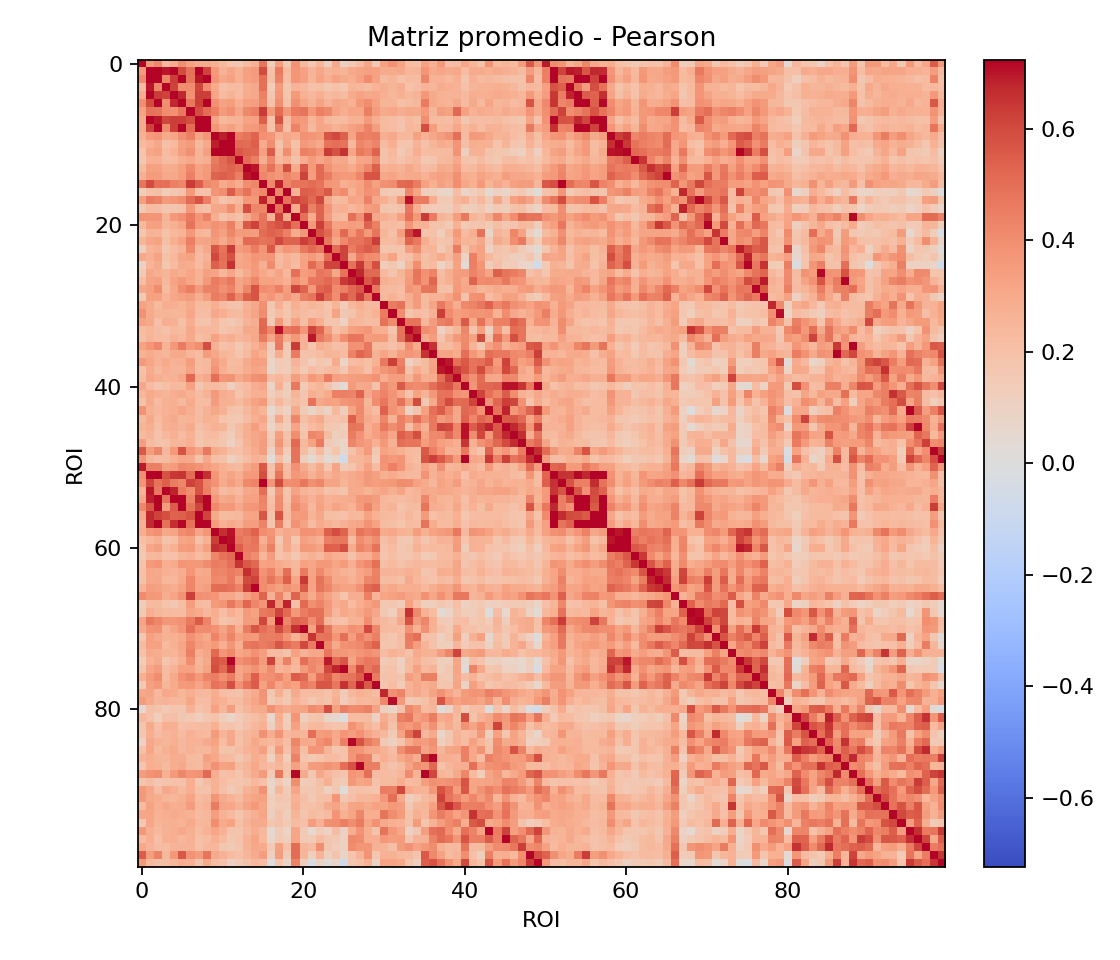


Matriz promedio: graphical_lasso


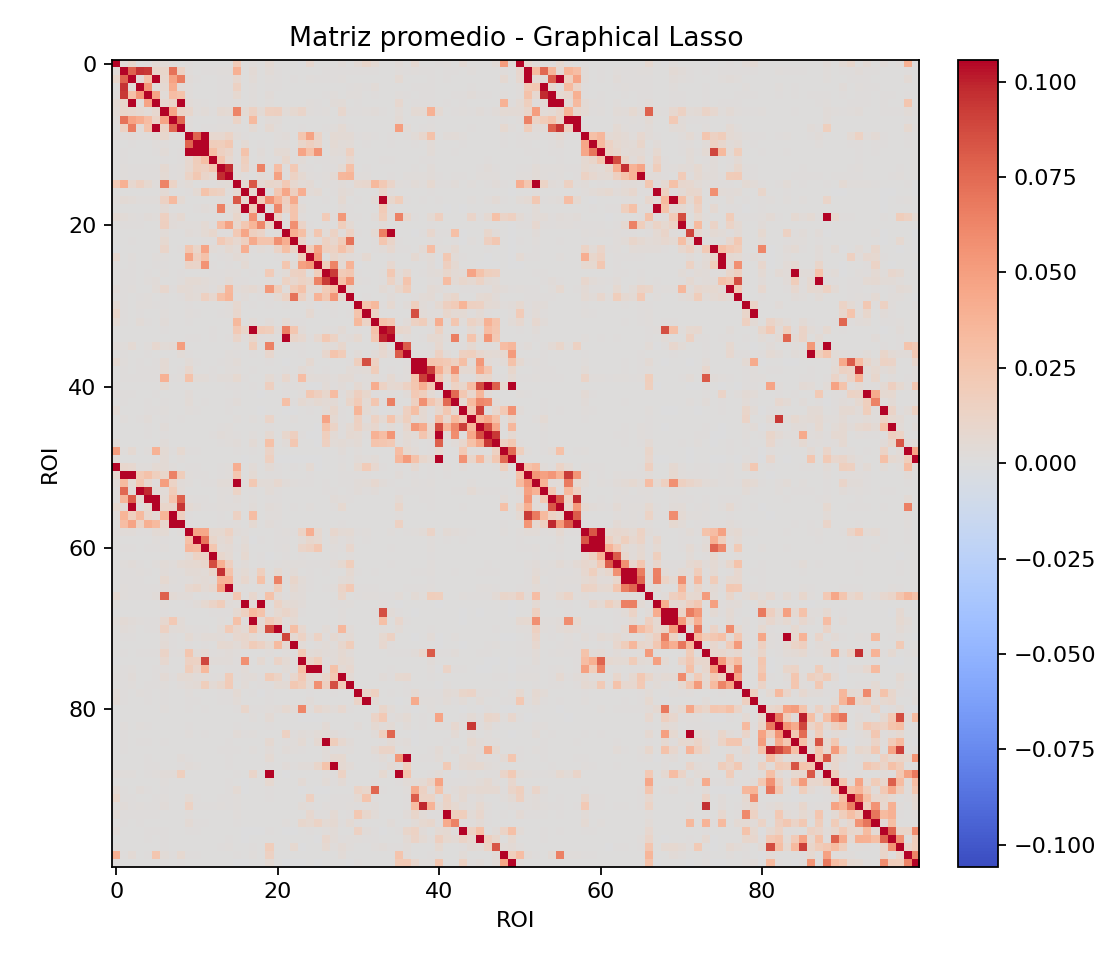


Matriz promedio: lingam


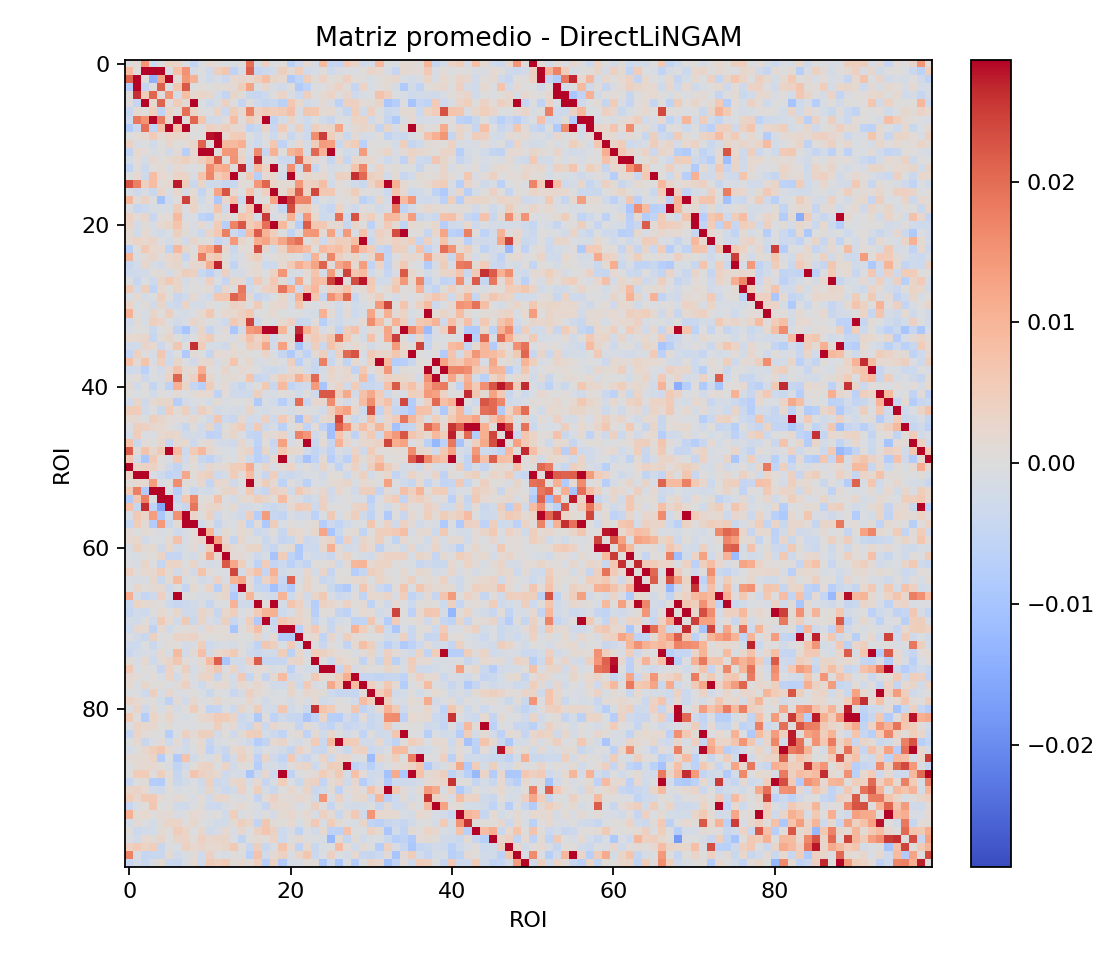

,method,imagen
0,pearson,resultados\pipeline_schaefer_100_all_valid_100...
1,graphical_lasso,resultados\pipeline_schaefer_100_all_valid_100...
2,lingam,resultados\pipeline_schaefer_100_all_valid_100...


RUN_SUBJECT_CONNECTOME_PLOTS=False: solo se muestran matrices promedio guardadas.


In [5]:
# CELDA 11 - Visualizar/comparar matrices promedio

from IPython.display import Image, display

imagenes_promedio = []
for method in METHODS_ORDER:
    img = OUT_RESULTS / f"matriz_promedio_{method}.png"
    if img.exists():
        imagenes_promedio.append({"method": method, "imagen": str(img)})
        print(f"\nMatriz promedio: {method}")
        display(Image(filename=str(img)))
    else:
        print(f"[AVISO] No encontre matriz promedio para {method}. Ejecuta primero su celda.")

if imagenes_promedio:
    display(pd.DataFrame(imagenes_promedio))

if RUN_SUBJECT_CONNECTOME_PLOTS:
    for method in METHODS_ORDER:
        img = OUT_RESULTS / f"matriz_promedio_{method}.png"
        if not img.exists():
            continue
        modo = "glass" if pipeline_abide.METHODS[method]["symmetric"] else "flechas3d"
        try:
            pipeline_abide.plot_conexiones_cerebro_sujeto(
                output_dir=OUT_RESULTS,
                file_id=FILE_ID_VISOR,
                method=method,
                top_n=20,
                modo=modo,
            )
        except Exception as exc:
            print(f"[AVISO] No pude graficar {method} para {FILE_ID_VISOR}: {exc}")
else:
    print("RUN_SUBJECT_CONNECTOME_PLOTS=False: solo se muestran matrices promedio guardadas.")


## 8. Vectorizar las matrices


In [6]:
# CELDA 12 - Vectorizar matrices calculadas

resumen_vectorizacion = []
for method in METHODS_ORDER:
    row = vectorizar_metodo(method)
    if row is not None:
        resumen_vectorizacion.append(row)
    else:
        resumen_vectorizacion.append(
            {
                "method": method,
                "simetrica": pipeline_abide.METHODS[method]["symmetric"],
                "n_subjects": np.nan,
                "n_features": np.nan,
                "X_path": "",
                "y_path": "",
            }
        )

resumen_vectorizacion = pd.DataFrame(resumen_vectorizacion)
display(resumen_vectorizacion)


Validacion features pearson: X=(723, 4950) | ASD=329 | Control=394 | simetrica=True
Validacion features graphical_lasso: X=(723, 4950) | ASD=329 | Control=394 | simetrica=True
Validacion features lingam: X=(723, 9900) | ASD=329 | Control=394 | simetrica=False


,method,simetrica,n_subjects,n_features,X_path,y_path
0,pearson,True,723,4950,resultados\pipeline_schaefer_100_all_valid_100...,resultados\pipeline_schaefer_100_all_valid_100...
1,graphical_lasso,True,723,4950,resultados\pipeline_schaefer_100_all_valid_100...,resultados\pipeline_schaefer_100_all_valid_100...
2,lingam,False,723,9900,resultados\pipeline_schaefer_100_all_valid_100...,resultados\pipeline_schaefer_100_all_valid_100...


## 9. Clasificar y comparar resultados


In [7]:
# CELDA 13 - Clasificar TEA y controles y comparar m?todos

_require_subjects()

groups = np.asarray([subject.site for subject in subjects])
all_results = []
table_rows = []
fold_metric_rows = []
prediction_rows = []
processing_summary_rows = []

fold_metric_columns = [
    "accuracy_fold_mean",
    "accuracy_fold_std",
    "balanced_accuracy_fold_mean",
    "balanced_accuracy_fold_std",
    "auc_fold_mean",
    "auc_fold_std",
    "f1_fold_mean",
    "f1_fold_std",
    "precision_fold_mean",
    "precision_fold_std",
    "recall_fold_mean",
    "recall_fold_std",
    "specificity_fold_mean",
    "specificity_fold_std",
]

for method in METHODS_ORDER:
    dataset = cargar_dataset_vectorizado(method)
    if dataset is None:
        note = method_failures.get(method, f"Sin dataset vectorizado para {method}.")
        print(f"[AVISO] {method}: {note}")
        for classifier in CLASSIFIERS_TO_RUN:
            row = {
                "method": method,
                "classifier": classifier,
                "status": "missing_vectorized_dataset",
                "n_subjects": len(subjects),
                "n_asd": int(sum(s.label == 1 for s in subjects)),
                "n_control": int(sum(s.label == 0 for s in subjects)),
                "n_features": np.nan,
                "n_splits": np.nan,
                "accuracy": np.nan,
                "auc": np.nan,
                "f1": np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "matrix_plot": str(OUT_RESULTS / f"matriz_promedio_{method}.png"),
                "note": note,
            }
            row.update({column: np.nan for column in fold_metric_columns})
            table_rows.append(row)
            pipeline_abide.append_processing_summary_rows(
                processing_summary_rows,
                subjects,
                method,
                classifier,
                metrics={},
                status="missing_vectorized_dataset",
                error_note=note,
            )
        continue

    X = dataset["X"]
    y = dataset["y"]
    matrix_plot = OUT_RESULTS / f"matriz_promedio_{method}.png"

    for classifier in CLASSIFIERS_TO_RUN:
        try:
            res = pipeline_abide.evaluate_classifier(
                X,
                y,
                classifier,
                n_splits=N_SPLITS,
                cv_strategy=CV_STRATEGY,
                groups=groups,
            )
            res["method"] = method
            all_results.append(res)
            pipeline_abide.append_subject_predictions(prediction_rows, subjects, method, classifier, res)
            pipeline_abide.append_processing_summary_rows(
                processing_summary_rows,
                subjects,
                method,
                classifier,
                metrics=res,
                status="ok",
                error_note="",
            )
            pipeline_abide.append_fold_metric_rows(fold_metric_rows, method, classifier, res)

            table_rows.append(
                {
                    "method": method,
                    "classifier": classifier,
                    "status": "ok",
                    "n_subjects": len(y),
                    "n_asd": int(np.sum(y == 1)),
                    "n_control": int(np.sum(y == 0)),
                    "n_features": X.shape[1],
                    "n_splits": res["n_splits"],
                    "accuracy": res["accuracy"],
                    "accuracy_fold_mean": res.get("accuracy_mean", np.nan),
                    "accuracy_fold_std": res.get("accuracy_std", np.nan),
                    "balanced_accuracy": res["balanced_accuracy"],
                    "balanced_accuracy_fold_mean": res.get("balanced_accuracy_mean", np.nan),
                    "balanced_accuracy_fold_std": res.get("balanced_accuracy_std", np.nan),
                    "auc": res["auc"],
                    "auc_fold_mean": res.get("auc_mean", np.nan),
                    "auc_fold_std": res.get("auc_std", np.nan),
                    "f1": res["f1"],
                    "f1_fold_mean": res.get("f1_mean", np.nan),
                    "f1_fold_std": res.get("f1_std", np.nan),
                    "precision": res["precision"],
                    "precision_fold_mean": res.get("precision_mean", np.nan),
                    "precision_fold_std": res.get("precision_std", np.nan),
                    "recall": res["recall"],
                    "recall_fold_mean": res.get("recall_mean", np.nan),
                    "recall_fold_std": res.get("recall_std", np.nan),
                    "specificity": res["specificity"],
                    "specificity_fold_mean": res.get("specificity_mean", np.nan),
                    "specificity_fold_std": res.get("specificity_std", np.nan),
                    "matrix_plot": str(matrix_plot),
                    "note": "",
                }
            )
        except ValueError as exc:
            note = str(exc)
            print(f"[AVISO] {method} + {classifier}: {note}")
            row = {
                "method": method,
                "classifier": classifier,
                "status": "skipped_insufficient_classes",
                "n_subjects": len(y),
                "n_asd": int(np.sum(y == 1)),
                "n_control": int(np.sum(y == 0)),
                "n_features": X.shape[1],
                "n_splits": np.nan,
                "accuracy": np.nan,
                "auc": np.nan,
                "f1": np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "matrix_plot": str(matrix_plot),
                "note": note,
            }
            row.update({column: np.nan for column in fold_metric_columns})
            table_rows.append(row)
            pipeline_abide.append_processing_summary_rows(
                processing_summary_rows,
                subjects,
                method,
                classifier,
                metrics={},
                status="skipped_insufficient_classes",
                error_note=note,
            )

roc_path = pipeline_abide.plot_roc_curves(all_results, OUT_RESULTS) if all_results else None
prediction_paths = pipeline_abide.save_prediction_tables(prediction_rows, OUT_RESULTS)
final_processing_path = pipeline_abide.save_final_processing_csv(processing_summary_rows, OUT_RESULTS)
fold_metrics_path = pipeline_abide.save_fold_metrics_table(fold_metric_rows, OUT_RESULTS)

matrix_summary_rows = []
for method in METHODS_ORDER:
    matrices, _ = cargar_matrices_metodo(method)
    if matrices is None:
        continue
    matrix_summary_rows.extend(pipeline_abide.summarize_connectivity_matrices(subjects, method, matrices))
matrix_summary_path = pipeline_abide.save_matrix_summary_table(matrix_summary_rows, OUT_RESULTS)

comparison_table = pd.DataFrame(table_rows)
if {"auc", "accuracy"}.issubset(comparison_table.columns):
    comparison_table = comparison_table.sort_values(["auc", "accuracy"], ascending=False, na_position="last")

table_path = OUT_RESULTS / "tabla_comparativa_resultados.csv"
comparison_table.to_csv(table_path, index=False)

edge_table_paths = {
    method: str(OUT_RESULTS / "conectividad_tablas" / f"{method}_edges.csv")
    for method in METHODS_ORDER
    if (OUT_RESULTS / "conectividad_tablas" / f"{method}_edges.csv").exists()
}
metadata = {
    "source": "nifti_atlas",
    "fmri_dir": str(DATA_DIR),
    "phenotypic_csv": str(PHENO),
    "atlas_name": ATLAS_NAME,
    "methods": METHODS_ORDER,
    "classifiers": CLASSIFIERS_TO_RUN,
    "n_per_group": N_PER_GROUP,
    "all_balanced": False if USE_ALL_VALID_SUBJECTS else ALL_BALANCED,
    "all_available": USE_ALL_VALID_SUBJECTS,
    "max_rois": MAX_ROIS,
    "min_timepoints": MIN_TIMEPOINTS,
    "maxlag": MAXLAG,
    "tau_max": TAU_MAX,
    "lingam_random_state": LINGAM_RANDOM_STATE,
    "granger_lag_strategy": GRANGER_LAG_STRATEGY,
    "pcmci_value_mode": PCMCI_VALUE_MODE,
    "graphical_lasso_alpha": GRAPHICAL_LASSO_ALPHA,
    "graphical_lasso_alpha_validation_summary_csv": str(OUT_RESULTS / "validacion_alpha_graphical_lasso_resumen.csv"),
    "graphical_lasso_alpha_validation_detail_csv": str(OUT_RESULTS / "validacion_alpha_graphical_lasso_detalle.csv"),
    "apply_bandpass": SUBJECT_SELECTION["apply_bandpass"],
    "cv_strategy": CV_STRATEGY,
    "stage_outputs": stage_paths if "stage_paths" in globals() else {},
    "timepoint_site_summary_csv": stage_paths.get("timepoints_by_site") if "stage_paths" in globals() else None,
    "prediction_tables": prediction_paths,
    "final_processing_csv": str(final_processing_path) if final_processing_path is not None else None,
    "fold_metrics_csv": str(fold_metrics_path) if fold_metrics_path is not None else None,
    "matrix_summary_csv": str(matrix_summary_path) if matrix_summary_path is not None else None,
    "connectivity_edge_tables": edge_table_paths,
    "roc_plot": str(roc_path) if roc_path is not None else None,
    "table": str(table_path),
}
(OUT_RESULTS / "configuracion_pipeline.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Tabla comparativa guardada en: {table_path}")
if fold_metrics_path is not None:
    print(f"Metricas por fold guardadas en: {fold_metrics_path}")
if matrix_summary_path is not None:
    print(f"Resumen de matrices guardado en: {matrix_summary_path}")
if roc_path is not None:
    print(f"Curvas ROC guardadas en: {roc_path}")
display(comparison_table)


Tabla comparativa guardada en: resultados\pipeline_schaefer_100_all_valid_100rois_tp146\tabla_comparativa_resultados.csv
Metricas por fold guardadas en: resultados\pipeline_schaefer_100_all_valid_100rois_tp146\metricas_por_fold.csv
Resumen de matrices guardado en: resultados\pipeline_schaefer_100_all_valid_100rois_tp146\resumen_matrices_conectividad.csv
Curvas ROC guardadas en: resultados\pipeline_schaefer_100_all_valid_100rois_tp146\curvas_roc.png


,method,classifier,status,n_subjects,n_asd,n_control,n_features,n_splits,accuracy,accuracy_fold_mean,...,precision_fold_mean,precision_fold_std,recall,recall_fold_mean,recall_fold_std,specificity,specificity_fold_mean,specificity_fold_std,matrix_plot,note
3,graphical_lasso,rf,ok,723,329,394,4950,5,0.607192,0.607004,...,0.683248,0.161920,0.349544,0.350587,0.076245,0.822335,0.848259,0.101495,resultados\pipeline_schaefer_100_all_valid_100...,
0,pearson,svm,ok,723,329,394,4950,5,0.647303,0.644196,...,0.673480,0.131793,0.559271,0.544064,0.071834,0.720812,0.751630,0.130581,resultados\pipeline_schaefer_100_all_valid_100...,
1,pearson,rf,ok,723,329,394,4950,5,0.612725,0.615843,...,0.689428,0.143522,0.401216,0.407197,0.140496,0.789340,0.824065,0.125317,resultados\pipeline_schaefer_100_all_valid_100...,
2,graphical_lasso,svm,ok,723,329,394,4950,5,0.539419,0.555095,...,0.554197,0.136006,0.550152,0.558701,0.228804,0.530457,0.579696,0.234554,resultados\pipeline_schaefer_100_all_valid_100...,
4,lingam,svm,ok,723,329,394,9900,5,0.539419,0.526012,...,0.333333,0.319722,0.051672,0.063523,0.073986,0.946701,0.945715,0.071668,resultados\pipeline_schaefer_100_all_valid_100...,
5,lingam,rf,ok,723,329,394,9900,5,0.484094,0.479317,...,0.322335,0.190914,0.206687,0.173348,0.183168,0.715736,0.793174,0.198080,resultados\pipeline_schaefer_100_all_valid_100...,


## Exploración adicional: tabla de conectividad Pearson


In [8]:
# CELDA 14 - Tabla completa de conectividad Pearson

pearson_edges_path = OUT_RESULTS / "conectividad_tablas" / "pearson_edges.csv"
if pearson_edges_path.exists():
    pearson_edges = pd.read_csv(pearson_edges_path)
    display(pearson_edges.head(30))
else:
    print("No encontre pearson_edges.csv. Ejecuta primero la celda de Pearson.")


,method,connectivity_family,subject_id,file_id,diagnosis,site,roi_origen,roi_destino,valor_conectividad,valor_abs
0,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_2,0.743337,0.743337
1,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_3,0.743517,0.743517
2,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_4,0.610002,0.610002
3,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_5,0.569097,0.569097
4,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_6,0.617119,0.617119
5,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_7,0.680073,0.680073
6,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_8,0.795336,0.795336
7,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_Vis_9,0.638027,0.638027
8,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_SomMot_1,0.652488,0.652488
9,pearson,asociativo,51461,Caltech_0051461,ASD,CALTECH,7Networks_LH_Vis_1,7Networks_LH_SomMot_2,0.674165,0.674165


## Exploración adicional: conexiones más fuertes de un sujeto


In [9]:
# CELDA 15 - Ver conexiones mas fuertes de un sujeto

file_id = FILE_ID_VISOR

if "pearson_edges" not in globals() and pearson_edges_path.exists():
    pearson_edges = pd.read_csv(pearson_edges_path)

if "pearson_edges" in globals():
    display(
        pearson_edges[pearson_edges["file_id"] == file_id]
        .sort_values("valor_abs", ascending=False)
        .head(20)
    )
else:
    print("No hay tabla Pearson cargada para inspeccionar conexiones.")


,method,connectivity_family,subject_id,file_id,diagnosis,site,roi_origen,roi_destino,valor_conectividad,valor_abs
1600195,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_SomMot_6,7Networks_RH_SomMot_8,0.958926,0.958926
1602523,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_1,0.952744,0.952744
1599662,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_Vis_9,7Networks_RH_Vis_8,0.951451,0.951451
1599570,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_Vis_8,7Networks_RH_Vis_7,0.944734,0.944734
1601291,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_SalVentAttn_Med_2,7Networks_RH_SalVentAttn_Med_1,0.942967,0.942967
1601000,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_SalVentAttn_FrOperIns_1,7Networks_RH_SalVentAttn_FrOperIns_1,0.942045,0.942045
1602852,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_RH_Vis_6,7Networks_RH_Default_pCunPCC_1,0.935591,0.935591
1603134,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_RH_SomMot_6,7Networks_RH_SomMot_7,0.935320,0.935320
1601833,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_Cont_Cing_1,7Networks_RH_Cont_Cing_1,0.935202,0.935202
1599932,pearson,asociativo,50003,Pitt_0050003,ASD,PITT,7Networks_LH_SomMot_3,7Networks_RH_SomMot_3,0.929063,0.929063


## Exploración adicional: visor con atlas


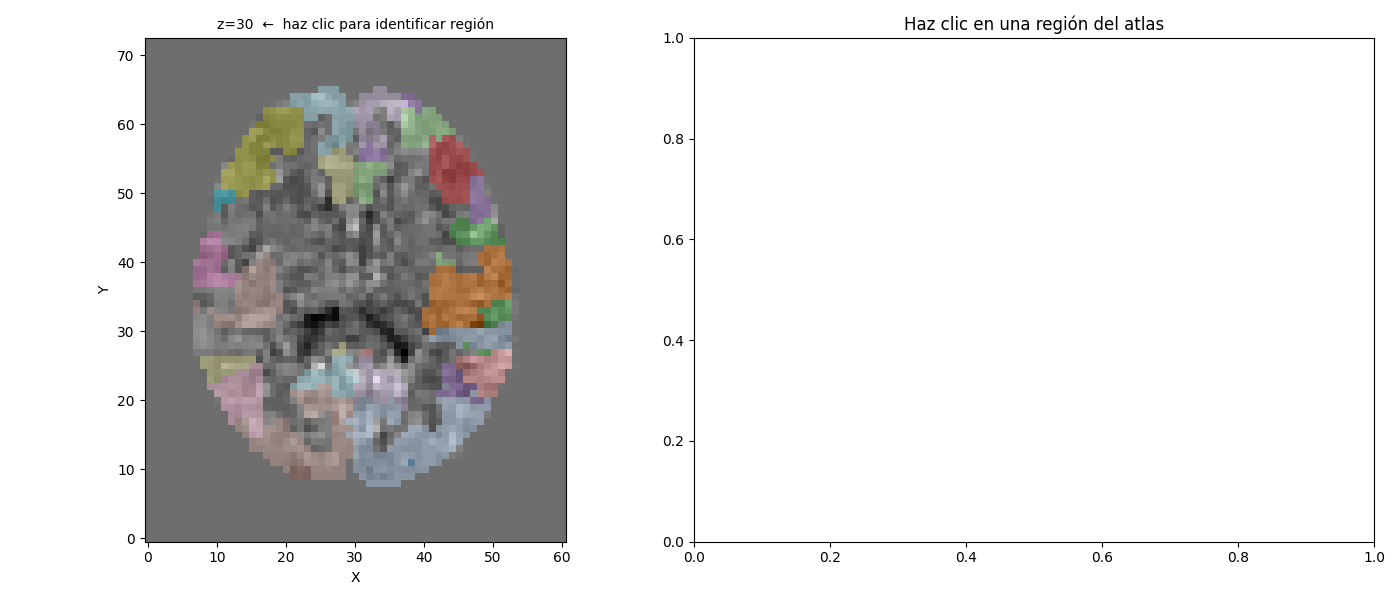

In [10]:
# CELDA 16 - Visor con atlas

%matplotlib widget

from script.visor import visor_parcelacion

file_id = FILE_ID_VISOR

v = pipeline_abide.preparar_visor_atlas_sujeto(
    output_dir=OUT_RESULTS,
    file_id=file_id,
)

visor_parcelacion(
    v["fmri_data"],
    v["atlas_data"],
    v["roi_signal_cache"],
    v["roi_name_map"],
    v["roi_ids_all"],
    v["roi_sizes_all"],
)


## Exploración adicional: visor de conectividad anatómica


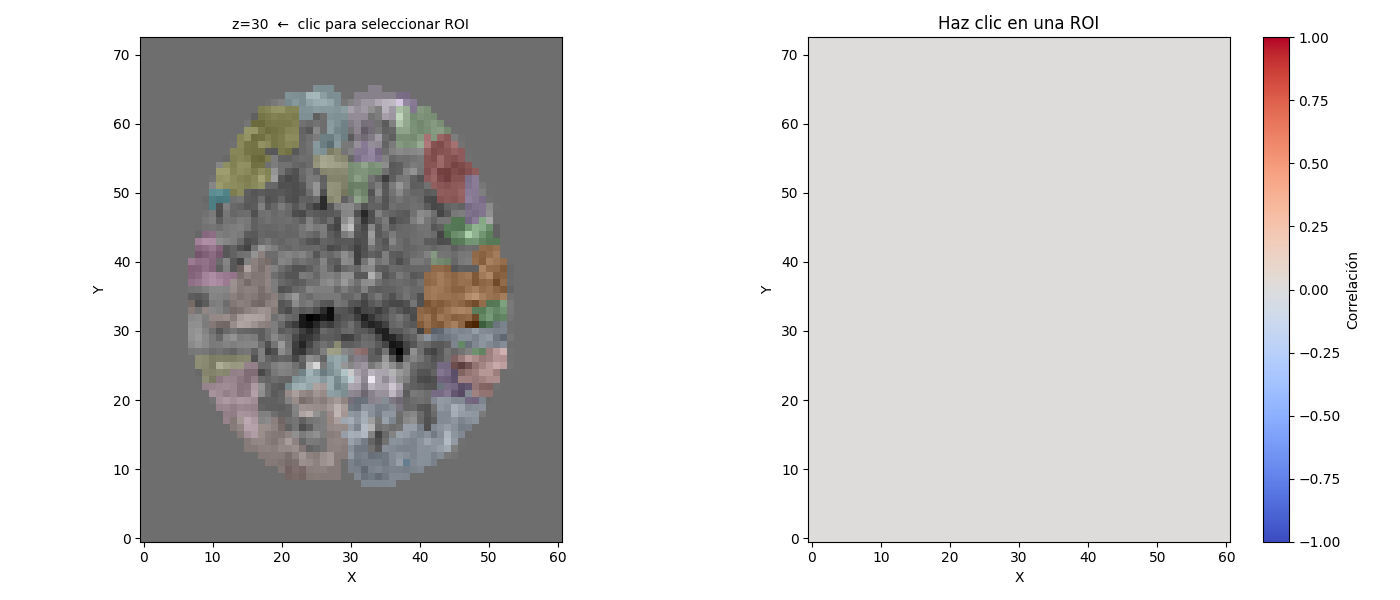

In [11]:
# CELDA 17 - Visor de conectividad anatomica desde ROI

from script.visor import visor_conectividad

visor_conectividad(
    v["fmri_data"],
    v["atlas_data"],
    v["roi_signal_cache"],
    v["roi_name_map"],
    v["roi_ids_all"],
)


In [12]:
from pathlib import Path

for method in METHODS_ORDER:
    folder = OUT_RESULTS / "matrices"
    matches = list(folder.glob(f"{method}_*rois/*_{method}.npy"))
    print(method, len(matches))


pearson 723
graphical_lasso 723
lingam 723


In [13]:
MIN_TIMEPOINTS_RULE = MIN_TIMEPOINTS if MIN_TIMEPOINTS is not None else subjects[0].roi_signals_z.shape[1] + 1

timepoints_by_site = pipeline_abide.build_timepoint_site_table(
    subjects,
    min_timepoints=MIN_TIMEPOINTS_RULE,
)

display(timepoints_by_site)


,site,n_subjects,asd,control,n_rois_min,n_rois_max,timepoints_min,timepoints_mean,timepoints_median,timepoints_max,timepoints_per_roi_min,n_t_le_rois,n_t_lt_2x_rois,min_timepoints_threshold,n_below_threshold
0,CALTECH,15,5,10,100,100,146,146.000000,146.0,146,1.46,0,15,146,0
1,CMU,11,6,5,100,100,202,254.727273,236.0,316,2.02,0,0,146,0
2,KKI,29,10,19,100,100,152,152.000000,152.0,152,1.52,0,29,146,0
3,LEUVEN_1,28,14,14,100,100,246,246.000000,246.0,246,2.46,0,0,146,0
4,LEUVEN_2,28,12,16,100,100,246,246.000000,246.0,246,2.46,0,0,146,0
5,MAX_MUN,12,7,5,100,100,196,196.000000,196.0,196,1.96,0,12,146,0
6,NYU,172,74,98,100,100,176,176.000000,176.0,176,1.76,0,172,146,0
7,OLIN,28,14,14,100,100,206,206.000000,206.0,206,2.06,0,0,146,0
8,PITT,50,24,26,100,100,196,196.000000,196.0,196,1.96,0,50,146,0
9,SBL,26,12,14,100,100,196,196.000000,196.0,196,1.96,0,26,146,0


In [14]:
base_subjects_for_filter = subjects_all_timepoints if "subjects_all_timepoints" in globals() else subjects
MIN_TIMEPOINTS_RULE = MIN_TIMEPOINTS if MIN_TIMEPOINTS is not None else base_subjects_for_filter[0].roi_signals_z.shape[1] + 1

subjects_filtrados = pipeline_abide.filter_subjects_by_timepoints(
    base_subjects_for_filter,
    min_timepoints=MIN_TIMEPOINTS_RULE,
)

display(
    pd.DataFrame(
        {
            "n_sujetos_base": [len(base_subjects_for_filter)],
            "n_sujetos_filtrados": [len(subjects_filtrados)],
            "n_excluidos": [len(base_subjects_for_filter) - len(subjects_filtrados)],
            "min_timepoints_filtro": [MIN_TIMEPOINTS_RULE],
            "min_timepoints_final": [min(s.roi_signals_z.shape[0] for s in subjects_filtrados)],
            "n_rois": [subjects_filtrados[0].roi_signals_z.shape[1]],
            "TEA": [sum(s.label == 1 for s in subjects_filtrados)],
            "Control": [sum(s.label == 0 for s in subjects_filtrados)],
        }
    )
)


,n_sujetos_base,n_sujetos_filtrados,n_excluidos,min_timepoints_filtro,min_timepoints_final,n_rois,ASD,Control
0,871,723,148,146,146,100,329,394


In [15]:
import pandas as pd
import numpy as np

tp_df = pd.DataFrame([
    {
        "file_id": s.file_id,
        "subject_id": s.subject_id,
        "label": s.label,
        "grupo": "TEA" if s.label == 1 else "Controles",
        "site": s.site,
        "timepoints": s.roi_signals_z.shape[0],
        "rois": s.roi_signals_z.shape[1],
    }
    for s in subjects
])

display(tp_df.sort_values("timepoints").head(20))

print("Sujetos:", len(tp_df))
print("Timepoints minimo:", tp_df["timepoints"].min())
print("Timepoints maximo:", tp_df["timepoints"].max())
print("Timepoints promedio:", round(tp_df["timepoints"].mean(), 2))
print("Timepoints mediana:", tp_df["timepoints"].median())

,file_id,subject_id,label,grupo,site,timepoints,rois
0,Caltech_0051461,51461,1,ASD,CALTECH,146,100
475,Trinity_0050263,50263,0,Control,TRINITY,146,100
476,Trinity_0050264,50264,0,Control,TRINITY,146,100
477,Trinity_0050265,50265,0,Control,TRINITY,146,100
478,Trinity_0050266,50266,0,Control,TRINITY,146,100
479,Trinity_0050267,50267,0,Control,TRINITY,146,100
480,Trinity_0050268,50268,0,Control,TRINITY,146,100
481,Trinity_0050269,50269,0,Control,TRINITY,146,100
482,Trinity_0050270,50270,0,Control,TRINITY,146,100
474,Trinity_0050262,50262,0,Control,TRINITY,146,100


Sujetos: 723
Timepoints minimo: 146
Timepoints maximo: 316
Timepoints promedio: 210.49
Timepoints mediana: 196.0


In [16]:
resumen_site = (
    tp_df.groupby("site")
    .agg(
        n_sujetos=("file_id", "count"),
        min_timepoints=("timepoints", "min"),
        mediana_timepoints=("timepoints", "median"),
        max_timepoints=("timepoints", "max"),
        asd=("label", lambda x: int((x == 1).sum())),
        control=("label", lambda x: int((x == 0).sum())),
    )
    .sort_values("min_timepoints")
)

display(resumen_site)

,n_sujetos,min_timepoints,mediana_timepoints,max_timepoints,asd,control
site,,,,,,
CALTECH,15,146,146.0,146,5,10
TRINITY,44,146,146.0,146,19,25
KKI,29,152,152.0,152,10,19
STANFORD,25,176,236.0,236,12,13
SDSU,27,176,176.0,176,8,19
NYU,172,176,176.0,176,74,98
SBL,26,196,196.0,196,12,14
PITT,50,196,196.0,196,24,26
MAX_MUN,12,196,196.0,196,7,5
